In [9]:
import pandas as pd
import os

# 设定文件路径
path = r"C:\Users\24401\Documents"

# 只读取 `Date` 和 `Price`
use_cols = ["Date", "Price"]
file_names = [
    "Stoxx 600 Banks Historical Data (6).csv",
    "Stoxx 600 Insurance PR Historical Data (3).csv",
    "Stoxx 600 Food & Beverage PR Historical Data (3).csv",
    "STOXX 600 Historical Data.csv",
    "Germany 3 Month Bond Yield Historical Data.csv"
]

# 读取并预处理数据
dfs = {name: pd.read_csv(os.path.join(path, name), usecols=use_cols) for name in file_names}

for df in dfs.values():
    df['Date'] = pd.to_datetime(df['Date'])  # 确保日期格式一致
    df['Price'] = pd.to_numeric(df['Price'])  # 确保价格是数值
    df.sort_values(by="Date", ascending=True, inplace=True)  # 确保时间顺序正确

# 变量分配
banks_df = dfs["Stoxx 600 Banks Historical Data (6).csv"]
insurance_df = dfs["Stoxx 600 Insurance PR Historical Data (3).csv"]
food_df = dfs["Stoxx 600 Food & Beverage PR Historical Data (3).csv"]
market_df = dfs["STOXX 600 Historical Data.csv"]
risk_free_df = dfs["Germany 3 Month Bond Yield Historical Data.csv"]

    

In [10]:
# 计算无风险利率（转换为周度）
risk_free_df['Risk_Free_Rate'] = ((1 + risk_free_df['Price'] / 100) ** (1/52)) - 1

In [11]:
# 确保 `Risk_Free_Rate` 计算正确
print("Risk-Free Rate (First 5 Rows):")
print(risk_free_df[['Date', 'Risk_Free_Rate']].head())


Risk-Free Rate (First 5 Rows):
          Date  Risk_Free_Rate
782 2010-01-03        0.000055
781 2010-01-10        0.000055
780 2010-01-17        0.000051
779 2010-01-24        0.000053
778 2010-01-31        0.000055


In [12]:
import numpy as np  
import pandas as pd

# 计算对数收益率（只使用 `Price`）
def compute_log_return(df):
    df['Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
    return df.dropna()  # 删除第一个 NaN 值（因为 shift(1) 造成的）

# 计算行业和市场收益率
banks_df = compute_log_return(banks_df)
insurance_df = compute_log_return(insurance_df)
food_df = compute_log_return(food_df)
market_df = compute_log_return(market_df)

# 只执行一次合并，避免重复 `merge()`
for df_name, df in zip(["banks_df", "insurance_df", "food_df", "market_df"], [banks_df, insurance_df, food_df, market_df]):
    if 'Risk_Free_Rate' not in df.columns:  
        df = df.merge(risk_free_df[['Date', 'Risk_Free_Rate']], on="Date", how="left")
    globals()[df_name] = df  # 重新赋值，确保变量更新

# 删除可能出现的 `_x` 和 `_y` 版本，防止数据混乱
for df_name, df in zip(["banks_df", "insurance_df", "food_df", "market_df"], [banks_df, insurance_df, food_df, market_df]):
    cols_to_drop = [col for col in df.columns if col.startswith("Risk_Free_Rate_")]
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    globals()[df_name] = df  # 更新变量


In [13]:
# 计算超额收益率
banks_df['Excess_Return'] = banks_df['Return'] - banks_df['Risk_Free_Rate']
insurance_df['Excess_Return'] = insurance_df['Return'] - insurance_df['Risk_Free_Rate']
food_df['Excess_Return'] = food_df['Return'] - food_df['Risk_Free_Rate']
market_df['Market_Excess_Return'] = market_df['Return'] - market_df['Risk_Free_Rate']



In [14]:
# 检查所有 DataFrame 是否存在 NaN 值
print("Banks DataFrame Missing Values:\n", banks_df.isna().sum(), "\n")
print("Insurance DataFrame Missing Values:\n", insurance_df.isna().sum(), "\n")
print("Food DataFrame Missing Values:\n", food_df.isna().sum(), "\n")
print("Market DataFrame Missing Values:\n", market_df.isna().sum(), "\n")
# 确保所有 DataFrame 的 Date 列一致
print("检查数据是否按日期对齐：")
print(all(banks_df['Date'] == insurance_df['Date']) and 
      all(banks_df['Date'] == food_df['Date']) and 
      all(banks_df['Date'] == market_df['Date']))
# 随机抽样 5 行，验证超额收益率计算是否正确
sample_check = banks_df.sample(5)
sample_check['Manual_Excess_Return'] = sample_check['Return'] - sample_check['Risk_Free_Rate']
print(sample_check[['Date', 'Return', 'Risk_Free_Rate', 'Excess_Return', 'Manual_Excess_Return']])


Banks DataFrame Missing Values:
 Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64 

Insurance DataFrame Missing Values:
 Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64 

Food DataFrame Missing Values:
 Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64 

Market DataFrame Missing Values:
 Date                    0
Price                   0
Return                  0
Risk_Free_Rate          0
Market_Excess_Return    0
dtype: int64 

检查数据是否按日期对齐：
True
          Date    Return  Risk_Free_Rate  Excess_Return  Manual_Excess_Return
164 2013-03-03  0.025042    3.268958e-06       0.025038              0.025038
488 2019-05-19 -0.030215   -1.077958e-04      -0.030107             -0.030107
239 2014-08-10  0.013465    7.692157e-07       0.013464              0.013464
628 2022-01-23  0.012883   -1.283035e-04    

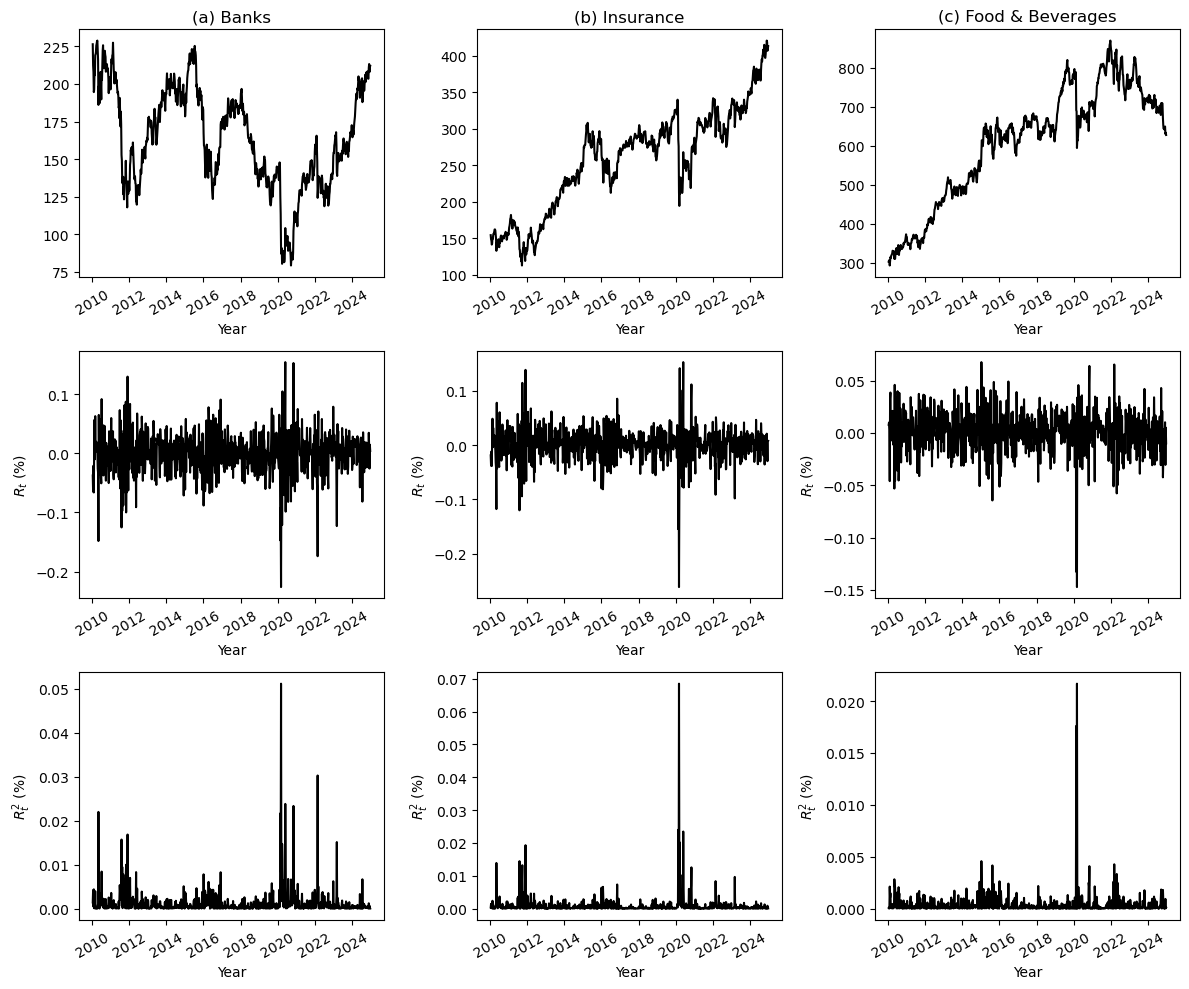

In [15]:
import matplotlib.pyplot as plt

# 直接使用已读取的 banks_df, insurance_df, food_df 数据
datasets = [banks_df, insurance_df, food_df]
titles = ["Banks", "Insurance", "Food & Beverages"]

# 生成 3x3 子图
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, df in enumerate(datasets):
    # 原始价格
    axes[0, i].plot(df['Date'], df['Price'], color='black')
    axes[0, i].set_title(f"({chr(97+i)}) {titles[i]}")

    # **超额收益率**
    axes[1, i].plot(df['Date'], df['Excess_Return'], color='black')
    axes[1, i].set_ylabel(r"$R_t$ (%)")

    # **超额收益率平方**
    axes[2, i].plot(df['Date'], df['Excess_Return']**2, color='black')
    axes[2, i].set_ylabel(r"$R_t^2$ (%)")

# 统一 X 轴格式
for ax in axes.flatten():
    ax.set_xlabel("Year")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()




In [16]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# 计算统计指标
def compute_statistics(df, sector_name, market_df):
    stats_dict = {}

    stats_dict["Sector"] = sector_name
    stats_dict["T"] = len(df)  # 样本数量
    stats_dict["Mean (%)"] = df["Excess_Return"].mean() * 100  # 均值转换为百分比
    stats_dict["Std Dev"] = df["Excess_Return"].std() * np.sqrt(52) * 100  # 标准差年化
    stats_dict["Skew"] = df["Excess_Return"].skew()  # 偏度
    stats_dict["Kurtosis"] = df["Excess_Return"].kurtosis()  # 峰度

    # Jarque-Bera 正态性检验
    jb_stat, jb_pval = stats.jarque_bera(df["Excess_Return"])
    stats_dict["JB"] = jb_stat

    # 修正 Ljung-Box Q 统计量（滞后12阶）
    lb_result = acorr_ljungbox(df["Excess_Return"].dropna(), lags=[12])
    stats_dict["Q(12)"] = lb_result.iloc[0, 0]  # ✅ 取第1行第1列数据

    # 检验 squared excess return 的 autocorrelation（lev 指标）
    squared_return = df["Excess_Return"].dropna() ** 2
    lev_result = acorr_ljungbox(squared_return, lags=[12])
    stats_dict["lev"] = lev_result.iloc[0, 0]  # ✅ 取第1行第1列数据

    # **计算 rho_oi（行业与市场的无条件相关性）**
    merged_df = df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    stats_dict["rho_oi"] = merged_df[["Excess_Return", "Market_Excess_Return"]].dropna().corr().iloc[0, 1]

    return stats_dict

# 确保 `banks_excess_return` 变量存在
banks_excess_return = banks_df[["Date", "Excess_Return"]].dropna()
insurance_excess_return = insurance_df[["Date", "Excess_Return"]].dropna()
food_excess_return = food_df[["Date", "Excess_Return"]].dropna()

# 计算统计数据
banks_stats = compute_statistics(banks_excess_return, "Banks", market_df)
insurance_stats = compute_statistics(insurance_excess_return, "Insurance", market_df)
food_stats = compute_statistics(food_excess_return, "Food & Beverage", market_df)

# 组合成 DataFrame
stats_df = pd.DataFrame([banks_stats, insurance_stats, food_stats])

# **直接打印结果**
print(stats_df)





            Sector    T  Mean (%)    Std Dev      Skew  Kurtosis           JB  \
0            Banks  782 -0.017046  26.091377 -0.555165  3.930902   535.138285   
1        Insurance  782  0.119767  22.414679 -0.822054  9.437873  2948.437808   
2  Food & Beverage  782  0.090513  14.377847 -0.956138  6.356314  1415.246710   

       Q(12)         lev    rho_oi  
0  13.893520  157.882194  0.825269  
1  23.240992  246.078867  0.892736  
2  10.854831  120.912426  0.760155  


In [17]:
print(banks_df[["Date", "Return", "Risk_Free_Rate", "Excess_Return"]].head(10))
print(insurance_df[["Date", "Return", "Risk_Free_Rate", "Excess_Return"]].head(10))
print(food_df[["Date", "Return", "Risk_Free_Rate", "Excess_Return"]].head(10))


        Date    Return  Risk_Free_Rate  Excess_Return
0 2010-01-10 -0.037374        0.000055      -0.037428
1 2010-01-17 -0.064456        0.000051      -0.064507
2 2010-01-24 -0.020854        0.000053      -0.020907
3 2010-01-31 -0.066127        0.000055      -0.066183
4 2010-02-07  0.009057        0.000052       0.009005
5 2010-02-14  0.056878        0.000054       0.056824
6 2010-02-21 -0.009962        0.000046      -0.010008
7 2010-02-28  0.062958        0.000044       0.062913
8 2010-03-07  0.002598        0.000055       0.002543
9 2010-03-14  0.006624        0.000055       0.006568
        Date    Return  Risk_Free_Rate  Excess_Return
0 2010-01-10 -0.018715        0.000055      -0.018770
1 2010-01-17 -0.037705        0.000051      -0.037756
2 2010-01-24 -0.011663        0.000053      -0.011715
3 2010-01-31 -0.038446        0.000055      -0.038502
4 2010-02-07  0.010435        0.000052       0.010383
5 2010-02-14  0.048867        0.000054       0.048813
6 2010-02-21 -0.003748      

In [18]:
print(banks_df["Date"].head(10))  # 确保日期按时间升序排列


0   2010-01-10
1   2010-01-17
2   2010-01-24
3   2010-01-31
4   2010-02-07
5   2010-02-14
6   2010-02-21
7   2010-02-28
8   2010-03-07
9   2010-03-14
Name: Date, dtype: datetime64[ns]


In [19]:
print(banks_df.isna().sum())
print(insurance_df.isna().sum())
print(food_df.isna().sum())


Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64
Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64
Date              0
Price             0
Return            0
Risk_Free_Rate    0
Excess_Return     0
dtype: int64


In [20]:
banks_df["Squared_Excess_Return"] = banks_df["Excess_Return"] ** 2
insurance_df["Squared_Excess_Return"] = insurance_df["Excess_Return"] ** 2
food_df["Squared_Excess_Return"] = food_df["Excess_Return"] ** 2


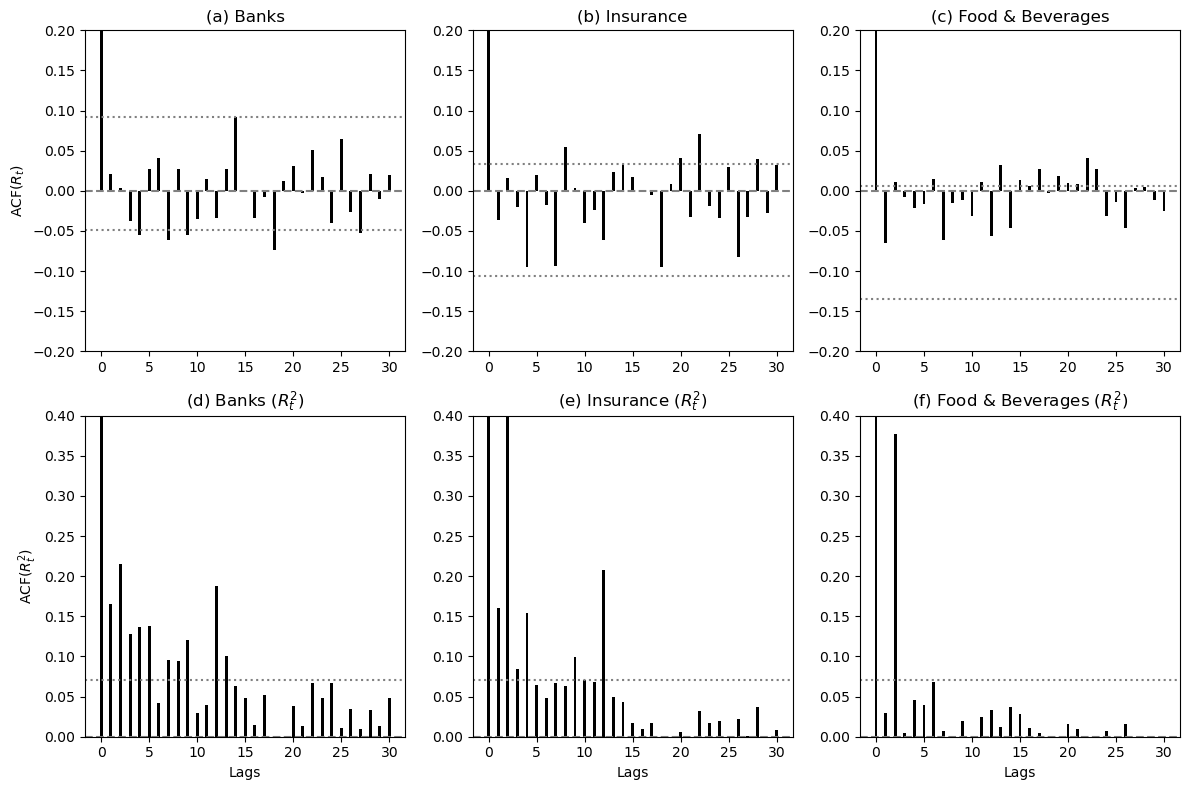

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# **重新计算 ACF**
def compute_acf(series, lags=30, symmetric_ci=False):
    """计算 ACF，并可选对称置信区间"""
    acf_values, confint = acf(series, nlags=lags, alpha=0.05)
    if symmetric_ci:
        confint_level = (confint[:, 1] - acf_values)  # 计算 ±1.96 标准误差范围
        return acf_values, confint_level
    return acf_values, confint  # 原始置信区间

# **去除 NaN**
banks_excess_return = banks_df[["Date", "Excess_Return"]].dropna()
insurance_excess_return = insurance_df[["Date", "Excess_Return"]].dropna()
food_excess_return = food_df[["Date", "Excess_Return"]].dropna()

# **创建绘图**
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# **第一行：超额收益率 ACF（保留双侧置信区间）**
for i, (df, title, ax) in enumerate(zip(
    [banks_excess_return, insurance_excess_return, food_excess_return],
    ["Banks", "Insurance", "Food & Beverages"],
    axes[0]
)):
    acf_values, confint = compute_acf(df["Excess_Return"], lags=30)
    ax.bar(range(31), acf_values, color='black', width=0.3)
    ax.axhline(0, linestyle='--', color='gray')
    ax.axhline(confint[:, 1][1], linestyle='dotted', color='gray')  # 上界
    ax.axhline(confint[:, 0][1], linestyle='dotted', color='gray')  # 下界
    ax.set_title(f"({chr(97+i)}) {title}")
    ax.set_ylim(-0.2, 0.2)  # 统一 Y 轴范围
    ax.set_xticks(range(0, 31, 5))

# **第二行：平方超额收益率 ACF（只绘制单条置信区间）**
for i, (df, title, ax) in enumerate(zip(
    [banks_excess_return, insurance_excess_return, food_excess_return],
    ["Banks", "Insurance", "Food & Beverages"],
    axes[1]
)):
    acf_values, confint_level = compute_acf(df["Excess_Return"]**2, lags=30, symmetric_ci=True)
    ax.bar(range(31), acf_values, color='black', width=0.3)
    ax.axhline(0, linestyle='--', color='gray')
    ax.axhline(confint_level[1], linestyle='dotted', color='gray')  # 只绘制单侧置信区间
    ax.set_title(f"({chr(100+i)}) {title} ($R_t^2$)")
    ax.set_ylim(0, 0.4)  # 统一 Y 轴范围
    ax.set_xticks(range(0, 31, 5))

# **美化**
for ax in axes[1]:
    ax.set_xlabel("Lags")

axes[0, 0].set_ylabel(r"ACF($R_t$)")
axes[1, 0].set_ylabel(r"ACF($R_t^2$)")

plt.tight_layout()
plt.show()


In [22]:
import statsmodels.api as sm  # ✅ 确保正确导入 statsmodels
import pandas as pd

# 估计 CAPM Beta
def estimate_capm_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on="Date", how="inner")

    X = df['Market_Excess_Return']
    Y = df['Excess_Return']

    X = sm.add_constant(X)  # 添加截距项
    model = sm.OLS(Y, X).fit()  # OLS 回归

    return model

# 计算行业 Beta
banks_beta = estimate_capm_beta(banks_df, market_df)
insurance_beta = estimate_capm_beta(insurance_df, market_df)
food_beta = estimate_capm_beta(food_df, market_df)

# 输出回归结果
print("Banks Beta:")
print(banks_beta.summary())

print("\nInsurance Beta:")
print(insurance_beta.summary())

print("\nFood & Beverage Beta:")
print(food_beta.summary())


Banks Beta:
                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     1666.
Date:                Wed, 26 Mar 2025   Prob (F-statistic):          9.56e-196
Time:                        19:47:19   Log-Likelihood:                 1933.3
No. Observations:                 782   AIC:                            -3863.
Df Residuals:                     780   BIC:                            -3853.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const               

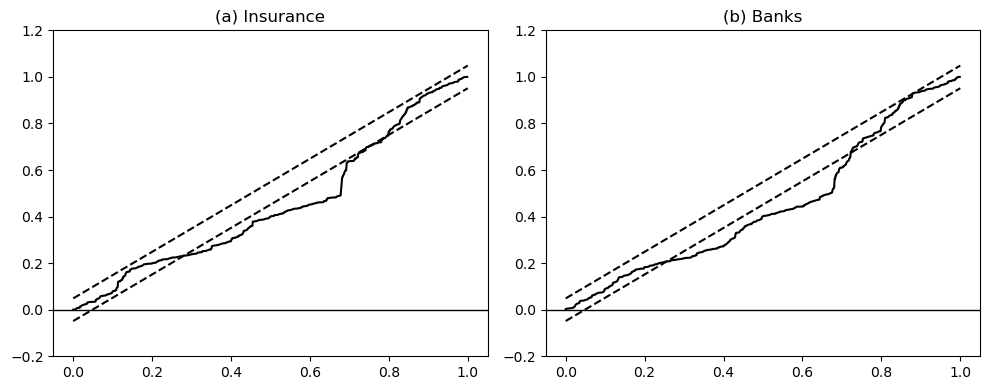

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 读取数据（替换 Food & Beverages 为 Banks）
insurance_df = insurance_excess_return.copy()
banks_df = banks_excess_return.copy()  # 替换 Food & Beverages
market_df = market_df.copy()

# 计算 CAPM 残差
def get_capm_residuals(sector_df, market_df):
    df = sector_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")

    # OLS 回归
    X = sm.add_constant(df["Market_Excess_Return"])  # 添加常数项 α
    model = sm.OLS(df["Excess_Return"], X).fit()
    
    return model.resid  # 返回残差 ε_t

insurance_residuals = get_capm_residuals(insurance_df, market_df)
banks_residuals = get_capm_residuals(banks_df, market_df)  # 替换 Food 为 Banks

# 计算 CUSUMSQ 统计量
def compute_cusumsq(residuals):
    T = len(residuals)
    S_t = np.cumsum(residuals**2) / np.sum(residuals**2)  # 归一化
    time = np.arange(T) / T  # 归一化时间轴
    return time, S_t

time_insurance, cusumsq_insurance = compute_cusumsq(insurance_residuals)
time_banks, cusumsq_banks = compute_cusumsq(banks_residuals)  # 替换 Food 为 Banks

# 计算 5% 置信区间
def cusumsq_confidence_interval(T):
    bound = 1.36 / np.sqrt(T)
    return np.linspace(0, 1, T), bound

conf_x, conf_bound = cusumsq_confidence_interval(len(insurance_residuals))

# 画图（Insurance & Banks）
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# **(a) Insurance**
axes[0].plot(time_insurance, cusumsq_insurance, color="black", label="CUSUMSQ test")
axes[0].plot(conf_x, conf_x + conf_bound, "k--", label="5% Confidence Interval")
axes[0].plot(conf_x, conf_x - conf_bound, "k--")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("(a) Insurance")
axes[0].set_ylim(-0.2, 1.2)

# **(b) Banks**
axes[1].plot(time_banks, cusumsq_banks, color="black", label="CUSUMSQ test")
axes[1].plot(conf_x, conf_x + conf_bound, "k--", label="5% Confidence Interval")
axes[1].plot(conf_x, conf_x - conf_bound, "k--")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("(b) Banks")
axes[1].set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()



# 模型 和 比较 的部分

In [24]:
import statsmodels.api as sm

# 定义函数：估计OLS CAPM beta
def estimate_capm_beta(industry_df, market_df, industry_name):
    # 合并市场超额收益率
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on='Date', how='inner')
    
    X = df['Market_Excess_Return']
    Y = df['Excess_Return']
    
    X = sm.add_constant(X)  # 添加常数项α
    model = sm.OLS(Y, X).fit()
    
    print(f"\n 回归结果：{industry_name}")
    print(model.summary())
    
    # 打印OLS估计的 beta 值
    print(f" OLS估计的 β（{industry_name}）为：{model.params['Market_Excess_Return']:.4f}")
    return model

# 分别估计三个行业的 beta
banks_ols = estimate_capm_beta(banks_df, market_df, "Banks")
insurance_ols = estimate_capm_beta(insurance_df, market_df, "Insurance")
food_ols = estimate_capm_beta(food_df, market_df, "Food & Beverages")



 回归结果：Banks
                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     1666.
Date:                Wed, 26 Mar 2025   Prob (F-statistic):          9.56e-196
Time:                        19:47:23   Log-Likelihood:                 1933.3
No. Observations:                 782   AIC:                            -3863.
Df Residuals:                     780   BIC:                            -3853.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const              

In [35]:
from pykalman import KalmanFilter
import numpy as np
import pandas as pd

def estimate_rw_kalman_em(industry_df, market_df, sector_name="Unnamed Sector"):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)

    y = df["Excess_Return"].values
    x = df["Market_Excess_Return"].values.reshape(-1, 1)
    observation_matrices = x.reshape(-1, 1, 1)

    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=observation_matrices,
        n_dim_obs=1,
        n_dim_state=1,
        em_vars=["initial_state_mean", "initial_state_covariance",
                 "observation_covariance", "transition_covariance"]
    )

    kf = kf.em(y, n_iter=50)  # 从50提到200
    state_means, _ = kf.filter(y)
    df["Beta_RW_EM"] = state_means.flatten()

    print(f" 完成 RW Kalman β（EM估计）：{sector_name}")
    return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_RW_EM"]], kf
def estimate_mr_kalman_em(industry_df, market_df, sector_name="Unnamed Sector"):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)

    y = df["Excess_Return"].values
    x = df["Market_Excess_Return"].values.reshape(-1, 1)

    # 构造观测矩阵 [x_t, x_t]
    observation_matrices = np.array([[r[0], r[0]] for r in x])
    observation_matrices = observation_matrices.reshape(-1, 1, 2)

    # 状态变量为 [β_t - β̄, β̄]
    transition_matrices = np.array([[0.9, 0],  # 初始 φ = 0.9，EM 会优化
                                    [0, 1]])

    kf = KalmanFilter(
        transition_matrices=transition_matrices,
        observation_matrices=observation_matrices,
        n_dim_obs=1,
        n_dim_state=2,
        em_vars=["initial_state_mean", "initial_state_covariance",
                 "observation_covariance", "transition_covariance"]
    )

    kf = kf.em(y, n_iter=50)  # 从50提到200

    state_means, _ = kf.filter(y)

    # 还原 β_t = (β_t - β̄) + β̄
    df["Beta_MR_EM"] = state_means[:, 0] + state_means[:, 1]

    print(f" 完成 MR Kalman β（EM估计）：{sector_name}")
    return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_MR_EM"]], kf



In [36]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

def estimate_rolling_beta(industry_df, market_df, sector_name="Unnamed Sector", window_size=52):
    # 合并行业和市场超额收益率
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    rolling_betas = []
    rolling_dates = []

    for i in range(window_size, len(df)):
        # 滚动窗口数据
        window_df = df.iloc[i - window_size:i]
        X = window_df["Market_Excess_Return"].values.reshape(-1, 1)
        y = window_df["Excess_Return"].values

        # OLS 线性回归估计 beta
        model = LinearRegression().fit(X, y)
        beta = model.coef_[0]

        # 存储 beta 与对应时间
        rolling_betas.append(beta)
        rolling_dates.append(df.iloc[i]["Date"])

    # 返回 DataFrame
    result = pd.DataFrame({
        "Date": rolling_dates,
        "Rolling_OLS_Beta": rolling_betas
    })

    print(f"📈 已完成 {sector_name} 的滚动窗口 beta 估计（窗口大小 = {window_size}）")
    return result


In [37]:
import matplotlib.pyplot as plt

def plot_beta_timeseries(beta_df):
    plt.figure(figsize=(12, 6))
    plt.plot(beta_df["Date"], beta_df["Rolling_OLS_Beta"], label="Rolling OLS Beta", color="blue")
    plt.plot(beta_df["Date"], beta_df["Beta_RW"], label="RW Kalman Beta", color="green")
    plt.plot(beta_df["Date"], beta_df["Beta_MR"], label="MR Kalman Beta", color="orange")
    plt.axhline(beta_df["OLS_Beta"].iloc[0], color="gray", linestyle="--", label="Static OLS Beta")
    
    plt.xlabel("Date")
    plt.ylabel("Beta")
    plt.title("Comparison of Beta Estimates Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [38]:
def plot_beta_boxplot(beta_df):
    df_trimmed = beta_df.iloc[50:]  # 剔除前 50 个估计值
    box_data = [
        df_trimmed["Rolling_OLS_Beta"],
        df_trimmed["Beta_RW"],
        df_trimmed["Beta_MR"]
    ]
    labels = ["Rolling OLS", "RW Kalman", "MR Kalman"]
    ols_beta = beta_df["OLS_Beta"].iloc[0]

    plt.figure(figsize=(8, 6))
    plt.boxplot(box_data, labels=labels, patch_artist=True)
    plt.axhline(ols_beta, color="gray", linestyle="--", label=f"Static OLS Beta = {ols_beta:.2f}")
    plt.title("Boxplot of Conditional Betas (Excl. First 50)")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [39]:
def print_beta_summary(beta_df):
    df_trimmed = beta_df.iloc[50:]  # 同样剔除前50项
    summary = {
        "Model": ["Rolling OLS", "RW Kalman", "MR Kalman"],
        "Mean": [
            df_trimmed["Rolling_OLS_Beta"].mean(),
            df_trimmed["Beta_RW"].mean(),
            df_trimmed["Beta_MR"].mean()
        ],
        "Range": [
            df_trimmed["Rolling_OLS_Beta"].max() - df_trimmed["Rolling_OLS_Beta"].min(),
            df_trimmed["Beta_RW"].max() - df_trimmed["Beta_RW"].min(),
            df_trimmed["Beta_MR"].max() - df_trimmed["Beta_MR"].min()
        ],
        "Std Dev": [
            df_trimmed["Rolling_OLS_Beta"].std(),
            df_trimmed["Beta_RW"].std(),
            df_trimmed["Beta_MR"].std()
        ]
    }

    summary_df = pd.DataFrame(summary)
    print("📊 Beta Summary (Excluding First 50 Observations):")
    print(summary_df.round(4))
    return summary_df


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


In [41]:
def estimate_ols_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on="Date", how="inner")
    X = df['Market_Excess_Return']
    Y = df['Excess_Return']
    return np.sum(X * Y) / np.sum(X ** 2)


In [42]:
#  1. 估计 RW Kalman beta，并重命名列为 Beta_RW
rw_df, _ = estimate_rw_kalman_em(banks_df, market_df, "Banks")
rw_df = rw_df.rename(columns={"Beta_RW_EM": "Beta_RW"})

#  2. MR Kalman beta
df_mr, _ = estimate_mr_kalman_em(banks_df, market_df, "Banks")
df_mr = df_mr.rename(columns={"Beta_MR_EM": "Beta_MR"})

#  3. 滚动 OLS beta
rolling_df = estimate_rolling_beta(banks_df, market_df, sector_name="Banks", window_size=52)

# 合并所有 beta
beta_df = df_mr[["Date", "Beta_MR"]].merge(
    rw_df[["Date", "Beta_RW"]], on="Date", how="inner"
).merge(
    rolling_df[["Date", "Rolling_OLS_Beta"]], on="Date", how="inner"
)

# 静态 OLS beta（常数列）
ols_beta = estimate_ols_beta(banks_df, market_df)
beta_df["OLS_Beta"] = ols_beta

# 清理缺失值
beta_df.dropna(inplace=True)


 完成 RW Kalman β（EM估计）：Banks
 完成 MR Kalman β（EM估计）：Banks
 已完成 Banks 的滚动窗口 beta 估计（窗口大小 = 52）


In [43]:
# 以 MR Kalman 的 df 为主线（它是你处理最全的）
beta_df = df_mr[["Date", "Beta_MR"]].copy()

# 合并 RW Kalman beta（列名是 Beta_RW）
beta_df = beta_df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")

# 合并 Rolling OLS beta
beta_df = beta_df.merge(rolling_df[["Date", "Rolling_OLS_Beta"]], on="Date", how="inner")

# 添加 OLS beta（常数列）
beta_df["OLS_Beta"] = ols_beta

# 最终检查并去除缺失值
beta_df.dropna(inplace=True)


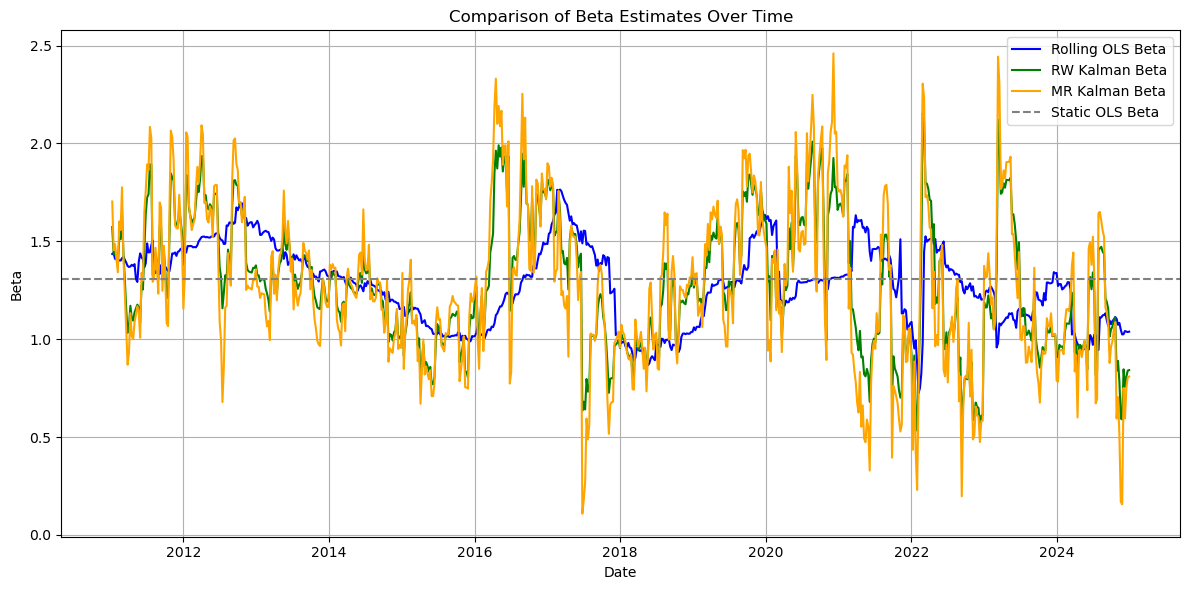

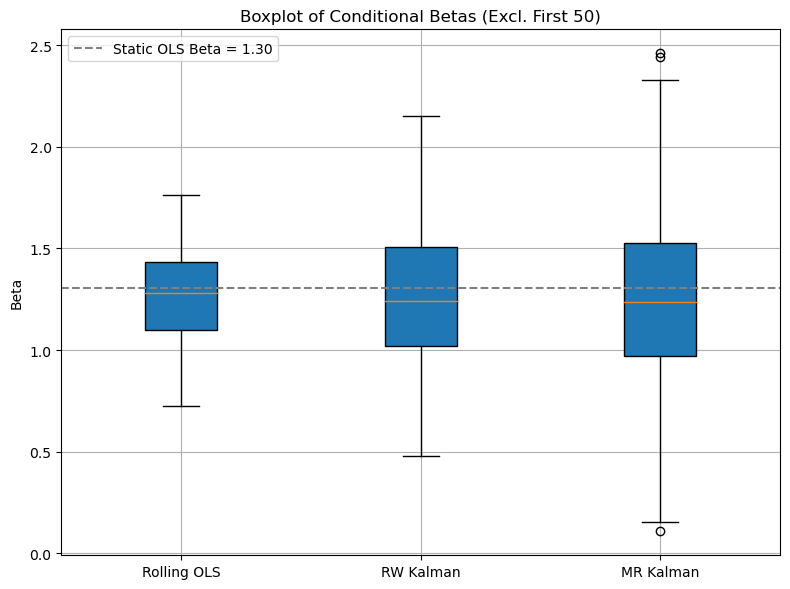

 Beta Summary (Excluding First 50 Observations):
         Model    Mean   Range  Std Dev
0  Rolling OLS  1.2717  1.0402   0.2063
1    RW Kalman  1.2718  1.6751   0.3309
2    MR Kalman  1.2598  2.3519   0.4090


In [44]:
# 绘制 beta 随时间变化图
plot_beta_timeseries(beta_df)

# 绘制 boxplot
plot_beta_boxplot(beta_df)

# 打印统计摘要
summary_df = print_beta_summary(beta_df)


# In-sample forecasting accuracy

In [27]:
from pykalman import KalmanFilter
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd


def evaluate_models_by_sector(industry_df, market_df, sector_name):
    # 合并数据
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 估计静态 OLS beta
    ols_beta = estimate_ols_beta(industry_df, market_df)
    df = df.copy()
    df["OLS_Beta"] = ols_beta

    # Rolling OLS beta
    rolling_df = estimate_rolling_beta(industry_df, market_df, sector_name)
    rolling_df = rolling_df.rename(columns={"Rolling_OLS_Beta": "Rolling_Beta"})

    # RW Kalman
    rw_df, _ = estimate_rw_kalman_em(industry_df, market_df, sector_name)
    rw_df = rw_df.rename(columns={"Beta_RW_EM": "Beta_RW"})

    # MR Kalman
    mr_df, _ = estimate_mr_kalman_em(industry_df, market_df, sector_name)
    mr_df = mr_df.rename(columns={"Beta_MR_EM": "Beta_MR"})

    # 截取对齐时间段的数据
    df = df[df["Date"].isin(rolling_df["Date"])
              & df["Date"].isin(rw_df["Date"])
              & df["Date"].isin(mr_df["Date"])]

    df = df.merge(rolling_df, on="Date", how="inner")
    df = df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")
    df = df.merge(mr_df[["Date", "Beta_MR"]], on="Date", how="inner")

    # 用 β × R_mkt 预测
    result = {"Sector": sector_name}
    y_true = df["Excess_Return"]
    r_mkt = df["Market_Excess_Return"]

    for model, col in {
        "OLS": "OLS_Beta",
        "Rolling OLS": "Rolling_Beta",
        "RW Kalman": "Beta_RW",
        "MR Kalman": "Beta_MR"
    }.items():
        y_pred = df[col] * r_mkt
        mae = np.mean(np.abs(y_true - y_pred))
        mse = np.mean((y_true - y_pred) ** 2)
        result[f"{model}_MAE"] = mae
        result[f"{model}_MSE"] = mse

    return result

# 多行业评估
sectors = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food": food_df
}

all_results = []
for name, df in sectors.items():
    result = evaluate_models_by_sector(df, market_df, name)
    all_results.append(result)

multi_sector_results_df = pd.DataFrame(all_results)


 已完成 Banks 的滚动窗口 beta 估计（窗口大小 = 52）
 完成 RW Kalman β（EM估计）：Banks
 完成 MR Kalman β（EM估计）：Banks
 已完成 Insurance 的滚动窗口 beta 估计（窗口大小 = 52）
 完成 RW Kalman β（EM估计）：Insurance
 完成 MR Kalman β（EM估计）：Insurance
 已完成 Food 的滚动窗口 beta 估计（窗口大小 = 52）
 完成 RW Kalman β（EM估计）：Food
 完成 MR Kalman β（EM估计）：Food


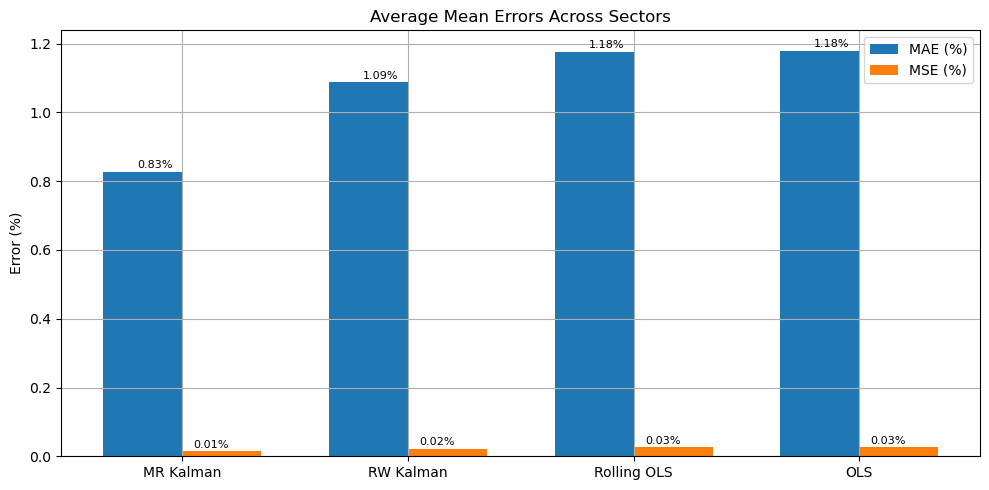

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 重新生成 error_df（原始误差）
models = ["OLS", "Rolling OLS", "RW Kalman", "MR Kalman"]

average_errors = {
    "Model": [],
    "MAE": [],
    "MSE": []
}

for model in models:
    average_errors["Model"].append(model)
    average_errors["MAE"].append(multi_sector_results_df[f"{model}_MAE"].mean())
    average_errors["MSE"].append(multi_sector_results_df[f"{model}_MSE"].mean())

error_df = pd.DataFrame(average_errors)

# 再次缩放为百分比
error_df["MAE (%)"] = error_df["MAE"] * 100
error_df["MSE (%)"] = error_df["MSE"] * 100

# 排序后绘图
error_df.sort_values("MAE (%)", inplace=True)
plt.figure(figsize=(10, 5))
x = np.arange(len(error_df))
width = 0.35

plt.bar(x - width/2, error_df["MAE (%)"], width, label="MAE (%)")
plt.bar(x + width/2, error_df["MSE (%)"], width, label="MSE (%)")

plt.xticks(x, error_df["Model"])
plt.ylabel("Error (%)")
plt.title("Average Mean Errors Across Sectors")
plt.legend()
plt.grid(True)

# 添加数值标签
for i in range(len(error_df)):
    plt.text(x[i] - 0.2, error_df["MAE (%)"].iloc[i] + 0.01, f'{error_df["MAE (%)"].iloc[i]:.2f}%', fontsize=8)
    plt.text(x[i] + 0.05, error_df["MSE (%)"].iloc[i] + 0.01, f'{error_df["MSE (%)"].iloc[i]:.2f}%', fontsize=8)

plt.tight_layout()
plt.show()



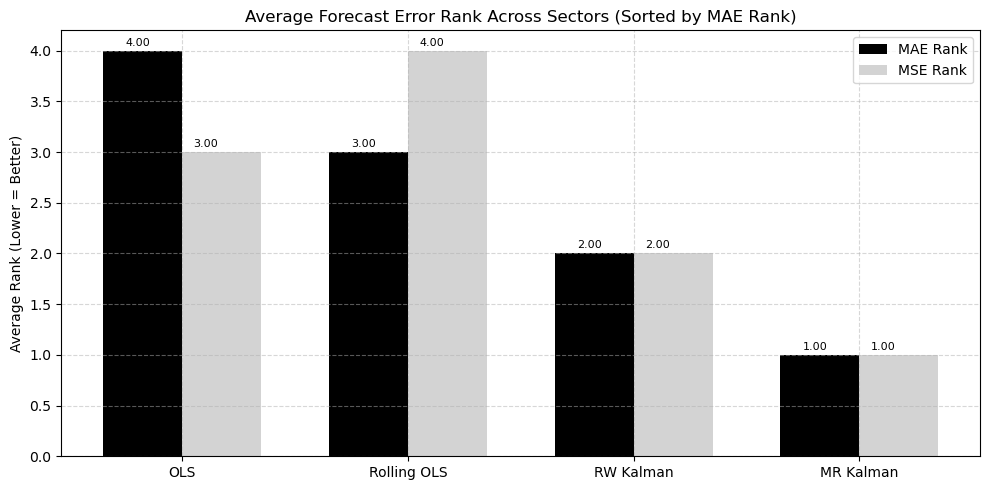

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 你已有的误差表 error_df 必须包含 MAE (%) 和 MSE (%)

# 计算排名（误差越小排名越高 → 排名 1 表示最好）
rank_df = error_df.copy()
rank_df["MAE Rank"] = rank_df["MAE (%)"].rank(method="min", ascending=True)
rank_df["MSE Rank"] = rank_df["MSE (%)"].rank(method="min", ascending=True)

# 按 MAE Rank 从高到低排序（即从差到好）
rank_df_sorted = rank_df.sort_values(by="MAE Rank", ascending=False).reset_index(drop=True)

# 开始绘图
x = np.arange(len(rank_df_sorted))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, rank_df_sorted["MAE Rank"], width, label="MAE Rank", color="black")
plt.bar(x + width/2, rank_df_sorted["MSE Rank"], width, label="MSE Rank", color="lightgray")

plt.xticks(x, rank_df_sorted["Model"])
plt.ylabel("Average Rank (Lower = Better)")
plt.title("Average Forecast Error Rank Across Sectors (Sorted by MAE Rank)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 添加排名标签
for i in range(len(rank_df_sorted)):
    plt.text(x[i] - 0.25, rank_df_sorted["MAE Rank"][i] + 0.05,
             f'{rank_df_sorted["MAE Rank"][i]:.2f}', fontsize=8)
    plt.text(x[i] + 0.05, rank_df_sorted["MSE Rank"][i] + 0.05,
             f'{rank_df_sorted["MSE Rank"][i]:.2f}', fontsize=8)

plt.tight_layout()
plt.show()


In [36]:
from scipy.stats import spearmanr

def calculate_spearman_ts(beta_dfs, beta_cols, market_df, sector_dfs):
    """
    beta_dfs: list of DataFrames（每个模型的 beta）
    beta_cols: 对应的 beta 列名列表，如 ["Rolling_OLS_Beta", "Beta_RW_EM", "Beta_MR_EM"]
    market_df: 包含 Market_Excess_Return 的 DataFrame
    sector_dfs: dict，如 {"Banks": banks_df, ...}

    返回：dates, spearman_results（字典）
    """
    spearman_results = {col: [] for col in beta_cols}
    dates = []

    date_list = beta_dfs[0]["Date"].values

    for idx, date in enumerate(date_list):
        predicted_returns = {col: [] for col in beta_cols}
        actual_returns = []

        skip = False
        for sector, sector_df in sector_dfs.items():
            actual = sector_df[sector_df["Date"] == date]["Excess_Return"]
            if actual.empty:
                skip = True
                break
            actual_returns.append(actual.values[0])

            r_mkt = market_df[market_df["Date"] == date]["Market_Excess_Return"]
            if r_mkt.empty:
                skip = True
                break
            r_mkt = r_mkt.values[0]

            for df, col in zip(beta_dfs, beta_cols):
                beta_val = df[df["Date"] == date][col]
                if beta_val.empty:
                    skip = True
                    break
                predicted_returns[col].append(beta_val.values[0] * r_mkt)

        if skip:
            continue

        for col in beta_cols:
            rho, _ = spearmanr(predicted_returns[col], actual_returns)
            spearman_results[col].append(rho)

        dates.append(date)

    return dates, spearman_results


In [37]:
def plot_spearman_ts(dates, spearman_results, beta_labels=None, smooth_window=20):
    """
    dates: 日期序列
    spearman_results: 字典，key 是模型名（列名），value 是 rho 序列
    beta_labels: 显示在图中的模型名称（如果不传，默认使用列名）
    smooth_window: 平滑窗口（建议 20）
    """
    plt.figure(figsize=(10, 5))

    if beta_labels is None:
        beta_labels = list(spearman_results.keys())

    for col, label in zip(spearman_results.keys(), beta_labels):
        series = pd.Series(spearman_results[col])
        smoothed = series.rolling(window=smooth_window, min_periods=1).mean()
        plt.plot(dates, smoothed, label=label)

    plt.title("In-Sample Spearman Rank Correlation Over Time")
    plt.xlabel("Date")
    plt.ylabel("Spearman’s ρ (Rank Correlation)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\24401\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


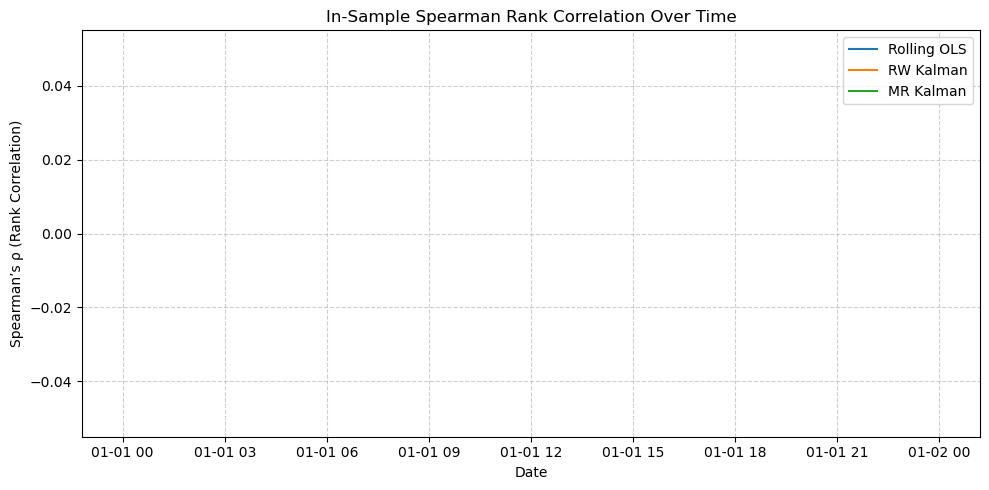

In [40]:
sector_dfs = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food": food_df
}

# 正确列名 & 顺序匹配
beta_dfs = [rolling_df, rw_df, df_mr]
beta_cols = ["Beta_Rolling", "Beta_RW", "Beta_MR"]
beta_labels = ["Rolling OLS", "RW Kalman", "MR Kalman"]

# 计算 Spearman 时间序列
dates, spearman_results = calculate_spearman_ts(
    beta_dfs=beta_dfs,
    beta_cols=beta_cols,
    market_df=market_df,
    sector_dfs=sector_dfs
)

# 绘图（平滑窗口可调）
plot_spearman_ts(dates, spearman_results, beta_labels=beta_labels, smooth_window=20)



In [39]:
print(rolling_df.columns)


Index(['Date', 'Beta_Rolling'], dtype='object')


In [41]:
# 看看这些 DataFrame 是否都有相同的日期
print("rolling_df 日期范围:", rolling_df["Date"].min(), rolling_df["Date"].max())
print("rw_df 日期范围:", rw_df["Date"].min(), rw_df["Date"].max())
print("df_mr 日期范围:", df_mr["Date"].min(), df_mr["Date"].max())

print("banks_df 日期范围:", banks_df["Date"].min(), banks_df["Date"].max())
print("market_df 日期范围:", market_df["Date"].min(), market_df["Date"].max())


rolling_df 日期范围: 2011-01-09 00:00:00 2024-12-29 00:00:00
rw_df 日期范围: 2010-01-10 00:00:00 2024-12-29 00:00:00
df_mr 日期范围: 2010-01-10 00:00:00 2024-12-29 00:00:00
banks_df 日期范围: 2010-01-10 00:00:00 2024-12-29 00:00:00
market_df 日期范围: 2010-01-10 00:00:00 2024-12-29 00:00:00


In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

# **定义 OLS 回归函数**
def estimate_capm_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on="Date", how="inner")
    
    X = df['Market_Excess_Return'] * 100  # 标准化数据
    Y = df['Excess_Return'] * 100  # 标准化数据
    
    X = sm.add_constant(X)  # 添加截距项
    model = sm.OLS(Y, X).fit()
    
    return model

# **对三个行业回归**
banks_beta = estimate_capm_beta(banks_df, market_df)
insurance_beta = estimate_capm_beta(insurance_df, market_df)
food_beta = estimate_capm_beta(food_df, market_df)

# **计算统计指标**
def get_ols_statistics(model, industry_df):
    alpha = model.params[0] * 100  # 转换为 x10^2 形式
    beta = model.params[1]
    r_squared = model.rsquared
    jb_stat, jb_pval = jarque_bera(industry_df["Excess_Return"].dropna())
    q_stat = acorr_ljungbox(industry_df["Excess_Return"].dropna(), lags=[12], return_df=True)["lb_stat"].values[0]
    lm_stat = het_arch(model.resid, maxlag=6)[0]  # LM(6) ARCH 检验

    # **显著性标注**
    def significance(value):
        if value < 0.01:
            return "***"
        elif value < 0.05:
            return "**"
        elif value < 0.1:
            return "*"
        return ""

    beta_sig = significance(model.pvalues[1])
    jb_sig = significance(jb_pval)
    
    # **修正 Q(12) 和 LM(6) 的显著性计算**
    q_sig = significance(0.01 if q_stat > 26.22 else (0.05 if q_stat > 21.03 else 1))
    lm_sig = significance(0.01 if lm_stat > 16.81 else (0.05 if lm_stat > 12.59 else 1))

    return [alpha, beta, beta_sig, r_squared, jb_stat, jb_sig, q_stat, q_sig, lm_stat, lm_sig]

# **整理为表格**
results = {
    "Sector": ["Banks", "Insurance", "Food & Beverages"],
    "α × 10²": [],
    "β": [],
    "R²": [],
    "JB": [],
    "Q(12)": [],
    "LM(6)": []
}

for model, industry_df in zip([banks_beta, insurance_beta, food_beta], [banks_df, insurance_df, food_df]):
    stats = get_ols_statistics(model, industry_df)
    results["α × 10²"].append(f"{stats[0]:.2f}")
    results["β"].append(f"{stats[1]:.2f}{stats[2]}")  # Beta + 显著性
    results["R²"].append(f"{stats[3]:.2f}")
    results["JB"].append(f"{stats[4]:.2f}{stats[5]}")  # JB + 显著性
    results["Q(12)"].append(f"{stats[6]:.2f}{stats[7]}")  # Q(12) + 显著性
    results["LM(6)"].append(f"{stats[8]:.2f}{stats[9]}")  # LM(6) + 显著性

# **转换为 DataFrame 并展示**
ols_df = pd.DataFrame(results)

# **打印结果**
print(ols_df)


NameError: name 'banks_df' is not defined

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model

def asymmetric_arch_tests(df, sector_name):
    df = df.dropna().copy()  # 删除缺失值
    df.set_index("Date", inplace=True)  # 确保索引为日期

    # **数据缩放**
    df["Excess_Return_Scaled"] = df["Excess_Return"] * 10  # 避免 DataScaleWarning

    # **建立 GARCH(1,1) 模型**
    garch_model = arch_model(df["Excess_Return_Scaled"], vol="Garch", p=1, q=1, mean="Constant", rescale=False)
    garch_results = garch_model.fit(disp="off")

    # **计算残差**
    df["Resid"] = garch_results.resid
    df["Resid^2"] = df["Resid"] ** 2

    # **创建回归变量**
    df["SB"] = np.where(df["Resid"].shift(1) < 0, df["Resid^2"], 0)
    df["NSB"] = np.where(df["Resid"].shift(1) < 0, df["Resid"], 0)  # 修正负偏误差
    df["PSB"] = np.where(df["Resid"].shift(1) > 0, df["Resid^2"], 0)

    # **确保数据完整性**
    X_SB = sm.add_constant(df["SB"].dropna())
    X_NSB = sm.add_constant(df["NSB"].dropna())
    X_PSB = sm.add_constant(df["PSB"].dropna())
    Y = df["Resid^2"].dropna()

    # **定义回归函数**
    def get_t_p_values(X, Y):
        common_index = X.index.intersection(Y.index)  # 确保索引一致
        X = X.loc[common_index]
        Y = Y.loc[common_index]
        model = sm.OLS(Y, X).fit()
        return model.tvalues[1], model.pvalues[1]

    SB_t, SB_p = get_t_p_values(X_SB, Y)
    NSB_t, NSB_p = get_t_p_values(X_NSB, Y)
    PSB_t, PSB_p = get_t_p_values(X_PSB, Y)

    return {
        "Sector": sector_name,
        "SB test": SB_t, "SB p-value": SB_p,
        "NSB test": NSB_t, "NSB p-value": NSB_p,
        "PSB test": PSB_t, "PSB p-value": PSB_p
    }

# **对银行、保险、食品行业进行测试**
banks_results = asymmetric_arch_tests(banks_df, "Banks")
insurance_results = asymmetric_arch_tests(insurance_df, "Insurance")
food_results = asymmetric_arch_tests(food_df, "Food & Beverages")

# **转换为 DataFrame 并打印**
results_df = pd.DataFrame([banks_results, insurance_results, food_results])

# 直接打印结果
print("\nAsymmetric ARCH Test Results:")
print(results_df.to_string(index=False))



In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model

# **定义 GARCH 规格测试函数**
def estimate_garch(df, sector_name, distribution="normal", asymmetric=False, mean_included=True):
    """
    估计不同规格的 GARCH(1,1) 模型：
    - distribution: "normal" 或 "t"
    - asymmetric: 是否使用非对称 GARCH（EGARCH）
    - mean_included: 是否包含均值项 μ
    """
    df = df.dropna().copy()
    df.set_index("Date", inplace=True)
    
    # **数据缩放**（避免 DataScaleWarning）
    df["Excess_Return_Scaled"] = df["Excess_Return"] * 10  

    # **选择 GARCH 规格**
    vol_model = "Garch"
    p, q = 1, 1
    if asymmetric:
        vol_model = "EGarch"  # 使用非对称 GARCH（考虑杠杆效应）

    # **建立 GARCH(1,1) 模型**
    garch = arch_model(df["Excess_Return_Scaled"], vol=vol_model, p=p, q=q, dist=distribution, rescale=False, mean="Constant" if mean_included else "Zero")
    
    # **拟合模型**
    results = garch.fit(disp="off")

    # **提取 log-likelihood 和 BIC**
    log_l = results.loglikelihood
    bic = results.bic
    
    return {"Sector": sector_name, "log L": log_l, "BIC": bic}

# **测试三种行业的不同 GARCH 规格**
sectors = {"Banks": banks_df, "Insurance": insurance_df, "Food & Beverages": food_df}
garch_results = []

for sector_name, df in sectors.items():
    for distribution in ["normal", "t"]:
        for asymmetric in [False, True]:
            for mean_included in [False, True]:
                result = estimate_garch(df, sector_name, distribution, asymmetric, mean_included)
                result["Distribution"] = "Normal" if distribution == "normal" else "Student-t"
                result["Asymmetric"] = "Yes" if asymmetric else "No"
                result["Mean Included"] = "Yes" if mean_included else "No"
                garch_results.append(result)

# **转换为 DataFrame**
garch_df = pd.DataFrame(garch_results)

# **打印结果（模拟 LaTeX 论文格式）**
print("\nGARCH(1,1) Specification Comparison:")
print(garch_df.to_string(index=False))


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model

# **GARCH(1,1) 估计函数**
def estimate_garch_t(industry_df, sector_name):
    df = industry_df.dropna().copy()
    df.set_index("Date", inplace=True)

    # **建立 t-GARCH(1,1) 模型**
    garch_model = arch_model(df["Excess_Return"] * 100, vol="Garch", p=1, q=1, dist="t")
    garch_results = garch_model.fit(disp="off")

    # **提取参数**
    mu = garch_results.params["mu"] * 100  # 转换为 x10² 形式
    omega = garch_results.params["omega"] * 10000  # 转换为 x10⁴ 形式
    alpha = garch_results.params["alpha[1]"]
    beta = garch_results.params["beta[1]"]
    nu = garch_results.params["nu"]  # t 分布的自由度参数

    # **修正 JB 统计量解包**
    jb_stat, jb_pval, skew, kurt = sm.stats.jarque_bera(garch_results.resid)
    q_stat = sm.stats.acorr_ljungbox(garch_results.resid, lags=[12], return_df=True)["lb_stat"].values[0]

    # **显著性标注**
    def significance(value):
        if value < 0.01:
            return "***"
        elif value < 0.05:
            return "**"
        elif value < 0.1:
            return "*"
        return ""

    return {
        "Sector": sector_name,
        "μ × 10²": f"{mu:.2f}",
        "ω × 10⁴": f"{omega:.2f}{significance(garch_results.pvalues['omega'])}",
        "γ": f"{alpha:.2f}{significance(garch_results.pvalues['alpha[1]'])}",
        "δ": f"{beta:.2f}{significance(garch_results.pvalues['beta[1]'])}",
        "DF": f"{nu:.2f}{significance(garch_results.pvalues['nu'])}",
        "JB": f"{jb_stat:.2f}{significance(0.05 if jb_stat > 5.99 else 1)}",
        "Q(12)": f"{q_stat:.2f}{significance(0.05 if q_stat > 21.03 else 1)}"
    }

# **对三个行业进行 t-GARCH(1,1) 估计**
banks_garch = estimate_garch_t(banks_df, "Banks")
insurance_garch = estimate_garch_t(insurance_df, "Insurance")
food_garch = estimate_garch_t(food_df, "Food & Beverages")

# **转换为 DataFrame 并打印**
garch_df = pd.DataFrame([banks_garch, insurance_garch, food_garch])
print("\nParameter Estimates for t-GARCH(1,1) Models:")
print(garch_df.to_string(index=False))

